# Road Traffic Accident Severity Analysis & Prediction — Eko Hospital

**Project Stakeholder: Eko Hospital**

This project analyzes 100 traffic accident records to identify accident patterns, hotspots, time-of-day trends, weather conditions, vehicle types, traffic density, and accident severity. A Random Forest classification model is used to predict accident severity from five available accident characteristics. The findings are translated into data-driven insights that can support Eko Hospital's emergency-response planning and resource-allocation decisions.

**Analytical scope:** descriptive analysis, hotspot and temporal analysis, accident-condition comparisons, and Random Forest classification. The existing analytical workflow and visualizations are preserved.


# Importing necessary libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

import warnings 
warnings.filterwarnings('ignore')

### Code Explanation:

#### **Step 1: Import Necessary Libraries**

- `import pandas as pd`: Imports the Pandas library for data manipulation, which is widely used for handling and analyzing data in tabular form (like CSV files).
  
- `import numpy as np`: Imports the NumPy library for numerical operations, such as handling arrays and performing mathematical computations.
  
- `import matplotlib.pyplot as plt`: Imports the Matplotlib library, which is used for creating visualizations like plots and graphs.

- `import seaborn as sns`: Imports Seaborn, a Python visualization library built on top of Matplotlib that provides a high-level interface for drawing attractive and informative statistical graphics.

- `from sklearn.model_selection import train_test_split`: 
  - `train_test_split`: Used to split data into training and testing sets for model evaluation.

- `from sklearn.preprocessing import LabelEncoder`: 
  - `LabelEncoder`: Used to encode categorical labels into numeric format, making it suitable for machine learning models.

- `from sklearn.ensemble import RandomForestClassifier`: 
  - `RandomForestClassifier`: Imports the Random Forest classifier, an ensemble learning method for classification tasks.

- `from sklearn.metrics import classification_report, confusion_matrix`: 
  - `classification_report`: Provides a detailed report on the performance of a classification model, including precision, recall, F1-score, etc.
  - `confusion_matrix`: Computes the confusion matrix, a table used to describe the performance of a classification model.

- `from sklearn.metrics import accuracy_score`: 
  - `accuracy_score`: Computes the accuracy of the model, which is the ratio of correct predictions to total predictions.

- `import warnings`: Imports the warnings module.

- `warnings.filterwarnings('ignore')`: Ignores any warnings that may arise during the execution of the code, ensuring a cleaner output.


# Data Preprocessing and Exploration

**Eko Hospital relevance:** Preparing the accident dataset creates a consistent analytical foundation for understanding patterns that may be relevant to emergency-response planning.

In [8]:
# Loading the dataset
df = pd.read_csv('/Users/mdshahriar/Downloads/Python Projects/Project 9/traffic_accident_data.csv')

# Checking for missing values and basic data exploration
print(df.isnull().sum())  # Check for missing values
print(df.describe())      # Summary statistics
print(df.dtypes)          # Data types

# Checking for duplicate entries
print(df.duplicated().sum())

Accident_ID           0
Location              0
Time_of_Day           0
Weather_Conditions    0
Vehicle_Type          0
Accident_Severity     0
Traffic_Density       0
Accident_Time         0
Accident_Hour         0
Injuries              0
Fatalities            0
dtype: int64
       Accident_Hour    Injuries  Fatalities
count     100.000000  100.000000  100.000000
mean       12.710000    2.380000    0.540000
std         6.320234    1.704302    0.500908
min         0.000000    0.000000    0.000000
25%         8.000000    1.000000    0.000000
50%        13.000000    2.000000    1.000000
75%        17.250000    4.000000    1.000000
max        23.000000    5.000000    1.000000
Accident_ID           object
Location              object
Time_of_Day           object
Weather_Conditions    object
Vehicle_Type          object
Accident_Severity     object
Traffic_Density       object
Accident_Time         object
Accident_Hour          int64
Injuries               int64
Fatalities             int64

### Code Explanation:

#### **Step 1: Load the Dataset**
- `df = pd.read_csv('/Users/mdshahriar/Downloads/Python Projects/Project 9/traffic_accident_data.csv')`:
  - This line loads the dataset from a CSV file located at the specified path (`'/Users/mdshahriar/Downloads/Python Projects/Project 9/traffic_accident_data.csv'`) into a Pandas DataFrame (`df`).
  - The `read_csv()` function is used to read CSV files and load them into a DataFrame for easy data manipulation and analysis.

#### **Step 2: Check for Missing Values and Basic Data Exploration**
- `print(df.isnull().sum())`:
  - This checks for missing values in each column of the DataFrame.
  - `isnull()` returns a DataFrame of the same shape as `df` with `True` for missing values and `False` for non-missing values.
  - `sum()` counts the number of missing values (i.e., `True` values) in each column.
  
- `print(df.describe())`:
  - This provides summary statistics for numerical columns in the DataFrame.
  - It returns the count, mean, standard deviation, min, max, and percentiles (25%, 50%, 75%) of the data for each numerical column.

- `print(df.dtypes)`:
  - This checks the data types of each column in the DataFrame.
  - It helps to identify whether each column has the appropriate data type (e.g., numeric, object/string, datetime, etc.).

#### **Step 3: Check for Duplicate Entries**
- `print(df.duplicated().sum())`:
  - This checks for duplicate rows in the dataset.
  - `duplicated()` returns a boolean Series where `True` indicates duplicate rows.
  - `sum()` counts how many duplicate rows exist in the DataFrame.



# Geospatial Analysis (Hotspot identification)

**Eko Hospital relevance:** Accident hotspot patterns can help contextualize where emergency demand may be concentrated and support resource-planning discussions.

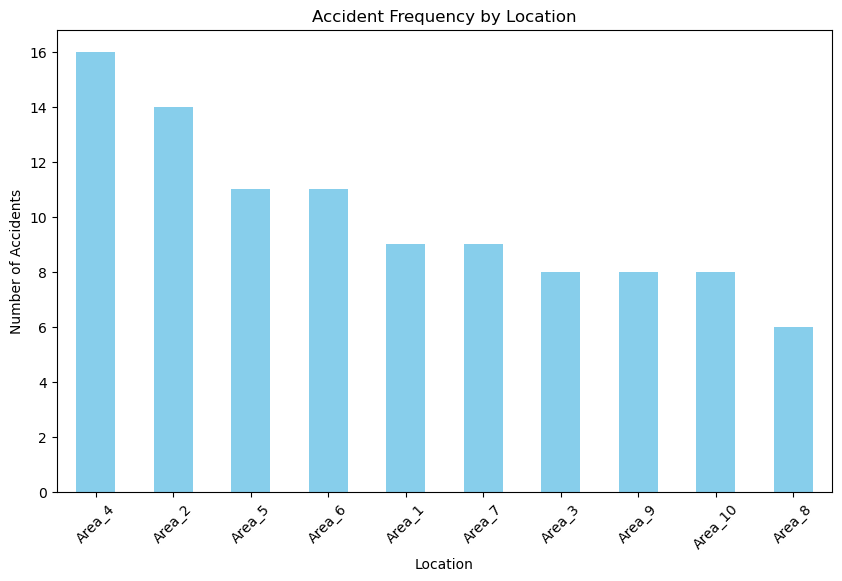

In [11]:
plt.figure(figsize=(10, 6))
location_counts = df['Location'].value_counts()
location_counts.plot(kind='bar', color='skyblue')
plt.title("Accident Frequency by Location")
plt.xlabel('Location')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

### Code Explanation:

#### **Step 1: Set Figure Size**
- `plt.figure(figsize=(10, 6))`:
  - This line sets the size of the plot to 10 inches wide by 6 inches tall. The `figsize` argument is used to define the dimensions of the figure for better visibility and presentation.

#### **Step 2: Count Accident Frequency by Location**
- `location_counts = df['Location'].value_counts()`:
  - This counts the occurrences of each unique value in the `Location` column of the DataFrame `df`.
  - `value_counts()` returns a Series with the count of each unique location, sorted in descending order.

#### **Step 3: Create a Bar Plot**
- `location_counts.plot(kind='bar', color='skyblue')`:
  - This creates a bar plot using the `location_counts` Series.
  - `kind='bar'` specifies that the plot should be a bar chart.
  - `color='skyblue'` sets the color of the bars to sky blue for better visual appeal.

#### **Step 4: Customize the Plot**
- `plt.title("Accident Frequency by Location")`:
  - This adds a title to the plot to describe the data being visualized.
  
- `plt.xlabel('Location')`:
  - This labels the x-axis as 'Location', indicating that the locations are plotted along the horizontal axis.

- `plt.ylabel('Number of Accidents')`:
  - This labels the y-axis as 'Number of Accidents', representing the frequency of accidents at each location.

- `plt.xticks(rotation=45)`:
  - This rotates the x-axis labels (locations) by 45 degrees to ensure they fit better and are readable if the labels are long.

#### **Step 5: Display the Plot**
- `plt.show()`:
  - This displays the plot in the Jupyter notebook.

# Temporal Analysis (Time of Day Patterns)

**Eko Hospital relevance:** Time-of-day patterns can help inform staffing and emergency-response readiness planning.

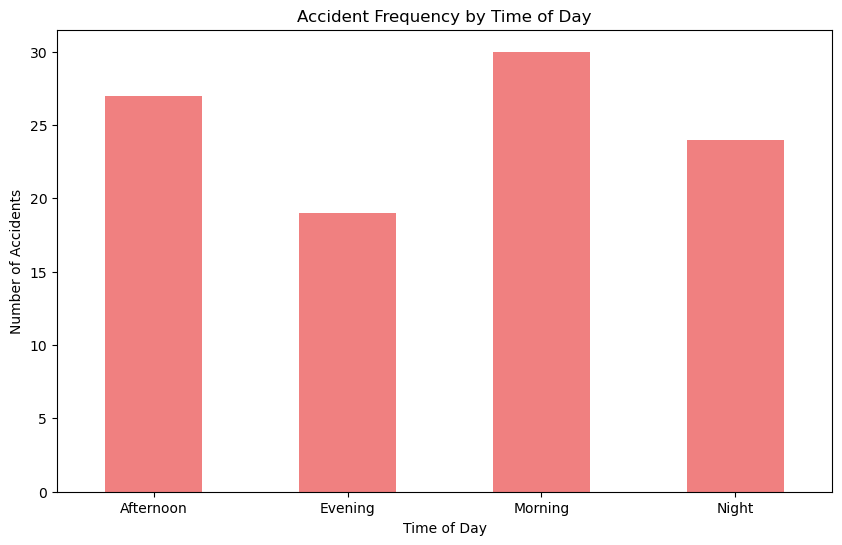

In [14]:
# Plotting accidents by time of day
plt.figure(figsize=(10, 6))
time_of_day_counts = df['Time_of_Day'].value_counts().sort_index()
time_of_day_counts.plot(kind='bar', color='lightcoral')
plt.title("Accident Frequency by Time of Day")
plt.xlabel('Time of Day')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.show()

### Code Explanation:

#### **Step 1: Set Figure Size**
- `plt.figure(figsize=(10, 6))`:
  - This line sets the size of the plot to 10 inches wide by 6 inches tall. The `figsize` argument ensures that the plot has adequate space for clarity.

#### **Step 2: Count Accident Frequency by Time of Day**
- `time_of_day_counts = df['Time_of_Day'].value_counts().sort_index()`:
  - This counts the occurrences of each unique value in the `Time_of_Day` column of the DataFrame `df`.
  - `value_counts()` returns the frequency of each unique value (time of day).
  - `sort_index()` sorts the values by the index (which could be the time, if it’s in a logical order), ensuring that the bar plot shows the data in a sorted sequence.

#### **Step 3: Create a Bar Plot**
- `time_of_day_counts.plot(kind='bar', color='lightcoral')`:
  - This creates a bar plot using the `time_of_day_counts` Series.
  - `kind='bar'` specifies that the plot should be a bar chart.
  - `color='lightcoral'` sets the color of the bars to light coral, enhancing the visual appeal.

#### **Step 4: Customize the Plot**
- `plt.title("Accident Frequency by Time of Day")`:
  - This sets the title of the plot, indicating that the data is showing the frequency of accidents based on the time of day.

- `plt.xlabel('Time of Day')`:
  - This labels the x-axis as 'Time of Day', indicating that the different times of day are plotted along the horizontal axis.

- `plt.ylabel('Number of Accidents')`:
  - This labels the y-axis as 'Number of Accidents', representing the frequency of accidents during each time period.

- `plt.xticks(rotation=0)`:
  - This sets the x-axis labels (times of day) to have no rotation (`rotation=0`), ensuring that the labels are displayed horizontally.

#### **Step 5: Display the Plot**
- `plt.show()`:
  - This displays the plot in the Jupyter notebook.

# Weather and Accident Severity Correlation

**Eko Hospital relevance:** Understanding weather-related accident patterns can provide context for periods when emergency services may experience different accident-related demands.

<Figure size 1000x600 with 0 Axes>

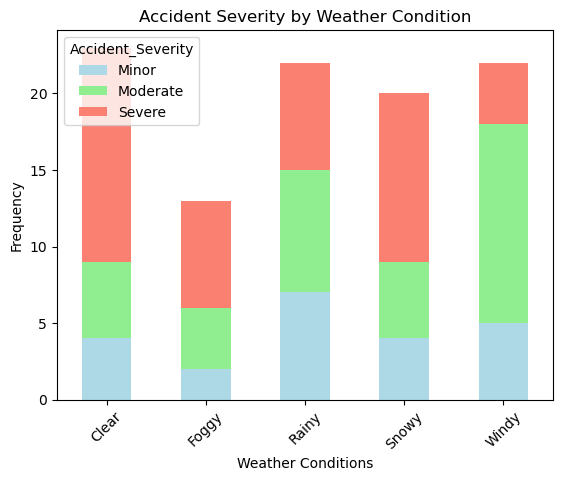

In [17]:
plt.figure(figsize=(10, 6))
weather_severity = pd.crosstab(df['Weather_Conditions'], df['Accident_Severity'])
weather_severity.plot(kind='bar', stacked=True, color=['lightblue', 'lightgreen', 'salmon'])
plt.title("Accident Severity by Weather Condition")
plt.xlabel('Weather Conditions')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

### Code Explanation:

#### **Step 1: Set Figure Size**
- `plt.figure(figsize=(10, 6))`:
  - This sets the figure size of the plot to 10 inches wide by 6 inches tall. It ensures that the plot has enough space to display the data clearly.

#### **Step 2: Create a Crosstab of Weather Conditions and Accident Severity**
- `weather_severity = pd.crosstab(df['Weather_Conditions'], df['Accident_Severity'])`:
  - This creates a crosstab (or contingency table) of the `Weather_Conditions` and `Accident_Severity` columns in the DataFrame `df`.
  - The crosstab shows the frequency of each combination of weather condition and accident severity, which allows you to analyze the relationship between the two variables.

#### **Step 3: Create a Stacked Bar Plot**
- `weather_severity.plot(kind='bar', stacked=True, color=['lightblue', 'lightgreen', 'salmon'])`:
  - This generates a stacked bar plot based on the `weather_severity` crosstab.
  - `kind='bar'` specifies that the plot should be a bar chart.
  - `stacked=True` makes the bars stacked, displaying the breakdown of accident severity within each weather condition.
  - The colors `lightblue`, `lightgreen`, and `salmon` are used to represent different levels of accident severity.

#### **Step 4: Customize the Plot**
- `plt.title("Accident Severity by Weather Condition")`:
  - This adds a title to the plot to describe the data being visualized, indicating that the plot shows accident severity based on weather conditions.

- `plt.xlabel('Weather Conditions')`:
  - This labels the x-axis as 'Weather Conditions', indicating that the weather conditions are plotted along the horizontal axis.

- `plt.ylabel('Frequency')`:
  - This labels the y-axis as 'Frequency', representing the number of accidents for each combination of weather condition and severity.

- `plt.xticks(rotation=45)`:
  - This rotates the x-axis labels by 45 degrees to improve readability, especially if the weather conditions are lengthy.

#### **Step 5: Display the Plot**
- `plt.show()`:
  - This displays the plot in the Jupyter notebook.

# Vehicle Type Analysis (Impact on Severity)

**Eko Hospital relevance:** Vehicle-type patterns provide additional context for anticipating the types of accident cases that may reach emergency services.

<Figure size 1000x600 with 0 Axes>

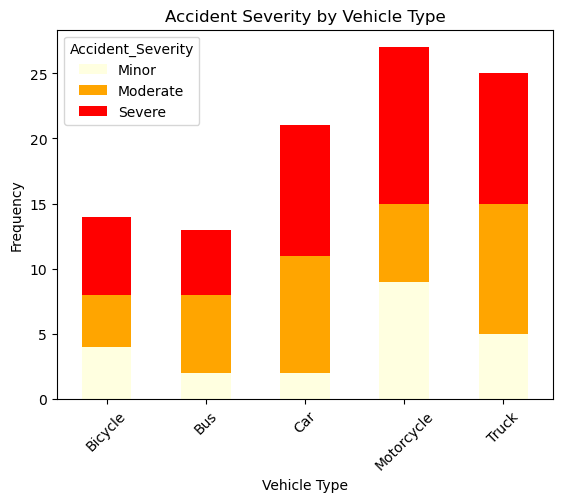

In [20]:
# Analyzing vehicle types and their severity
plt.figure(figsize=(10, 6))
vehicle_severity = pd.crosstab(df['Vehicle_Type'], df['Accident_Severity'])
vehicle_severity.plot(kind='bar', stacked=True, color=['lightyellow', 'orange', 'red'])
plt.title("Accident Severity by Vehicle Type")
plt.xlabel('Vehicle Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


### Code Explanation:

#### **Step 1: Set Figure Size**
- `plt.figure(figsize=(10, 6))`:
  - This sets the size of the plot to 10 inches wide by 6 inches tall, ensuring that the plot has sufficient space to display the data clearly.

#### **Step 2: Create a Crosstab of Vehicle Types and Accident Severity**
- `vehicle_severity = pd.crosstab(df['Vehicle_Type'], df['Accident_Severity'])`:
  - This creates a crosstab (or contingency table) of the `Vehicle_Type` and `Accident_Severity` columns in the DataFrame `df`.
  - The crosstab shows the frequency of accidents for each combination of vehicle type and accident severity, allowing for an analysis of the relationship between these two variables.

#### **Step 3: Create a Stacked Bar Plot**
- `vehicle_severity.plot(kind='bar', stacked=True, color=['lightyellow', 'orange', 'red'])`:
  - This generates a stacked bar plot based on the `vehicle_severity` crosstab.
  - `kind='bar'` specifies that the plot should be a bar chart.
  - `stacked=True` ensures the bars are stacked, displaying the breakdown of accident severity for each vehicle type.
  - The colors `lightyellow`, `orange`, and `red` are used to represent different levels of accident severity.

#### **Step 4: Customize the Plot**
- `plt.title("Accident Severity by Vehicle Type")`:
  - This adds a title to the plot, indicating that the data is showing the relationship between vehicle type and accident severity.

- `plt.xlabel('Vehicle Type')`:
  - This labels the x-axis as 'Vehicle Type', indicating that the vehicle types are plotted along the horizontal axis.

- `plt.ylabel('Frequency')`:
  - This labels the y-axis as 'Frequency', which represents the number of accidents for each vehicle type and severity combination.

- `plt.xticks(rotation=45)`:
  - This rotates the x-axis labels by 45 degrees to ensure that they are readable, especially if the vehicle types are long.

#### **Step 5: Display the Plot**
- `plt.show()`:
  - This displays the plot in the Jupyter notebook.



# Traffic Density Analysis (Impact on Frequency and Severity)

**Eko Hospital relevance:** Traffic-density patterns can contribute to broader emergency-response planning around periods of higher accident occurrence.

<Figure size 1000x600 with 0 Axes>

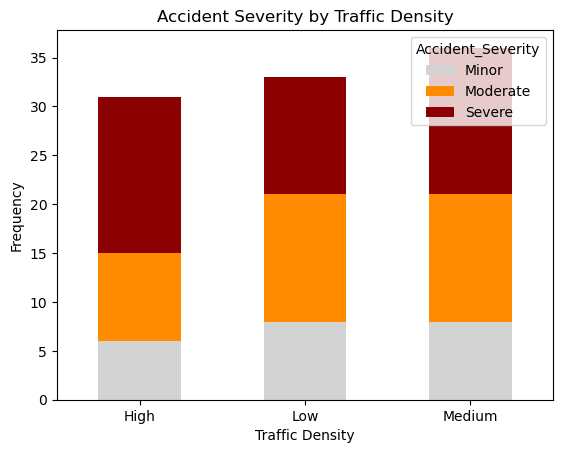

In [23]:
# Plotting traffic density against accident frequency and severity
plt.figure(figsize=(10, 6))
traffic_density_severity = pd.crosstab(df['Traffic_Density'], df['Accident_Severity'])
traffic_density_severity.plot(kind='bar', stacked=True, color=['lightgray', 'darkorange', 'darkred'])
plt.title("Accident Severity by Traffic Density")
plt.xlabel('Traffic Density')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

### Code Explanation:

#### **Step 1: Set Figure Size**
- `plt.figure(figsize=(10, 6))`:
  - This sets the figure size of the plot to 10 inches wide by 6 inches tall, ensuring that the plot has enough space for clarity and readability.

#### **Step 2: Create a Crosstab of Traffic Density and Accident Severity**
- `traffic_density_severity = pd.crosstab(df['Traffic_Density'], df['Accident_Severity'])`:
  - This creates a crosstab (contingency table) between the `Traffic_Density` and `Accident_Severity` columns in the DataFrame `df`.
  - The crosstab shows the frequency of accidents for each combination of traffic density and accident severity, helping to analyze the relationship between traffic conditions and accident outcomes.

#### **Step 3: Create a Stacked Bar Plot**
- `traffic_density_severity.plot(kind='bar', stacked=True, color=['lightgray', 'darkorange', 'darkred'])`:
  - This generates a stacked bar plot using the `traffic_density_severity` crosstab.
  - `kind='bar'` specifies that the plot should be a bar chart.
  - `stacked=True` stacks the bars, showing the breakdown of accident severity within each traffic density level.
  - The colors `lightgray`, `darkorange`, and `darkred` are used to represent different levels of accident severity, helping to visually distinguish between them.

#### **Step 4: Customize the Plot**
- `plt.title("Accident Severity by Traffic Density")`:
  - This adds a title to the plot, indicating that the data represents the relationship between traffic density and accident severity.

- `plt.xlabel('Traffic Density')`:
  - This labels the x-axis as 'Traffic Density', indicating that traffic density levels are plotted along the horizontal axis.

- `plt.ylabel('Frequency')`:
  - This labels the y-axis as 'Frequency', representing the number of accidents occurring at each level of traffic density and severity.

- `plt.xticks(rotation=0)`:
  - This sets the x-axis labels (traffic density levels) to be displayed without rotation (`rotation=0`), making them easier to read.

#### **Step 5: Display the Plot**
- `plt.show()`:
  - This displays the plot in the Jupyter notebook.

# Injury and Fatality Analysis (Impact of Conditions)

**Eko Hospital relevance:** Injury and fatality patterns are directly relevant to understanding the potential emergency-care burden associated with road traffic accidents.

<Figure size 1000x600 with 0 Axes>

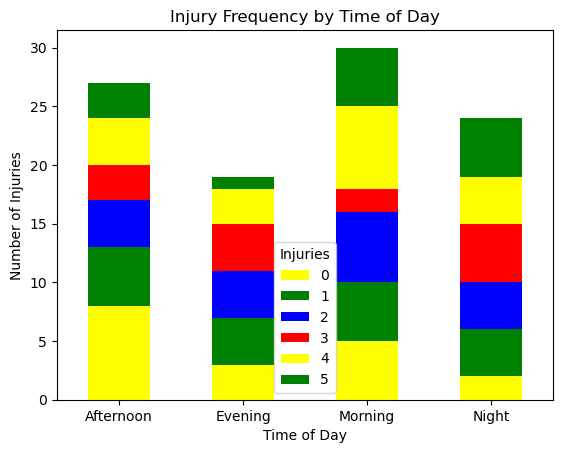

<Figure size 1000x600 with 0 Axes>

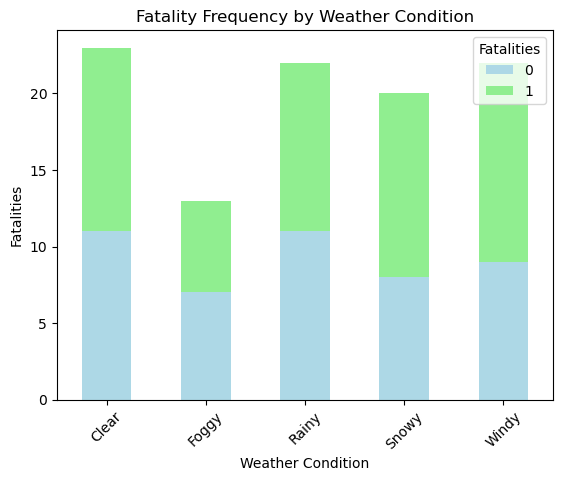

In [26]:
# Analyzing how accident conditions influence injuries and fatalities
plt.figure(figsize=(10, 6))
injury_fatality_conditions = pd.crosstab(df['Time_of_Day'], df['Injuries'])
injury_fatality_conditions.plot(kind='bar', stacked=True, color=['yellow', 'green', 'blue', 'red'])
plt.title("Injury Frequency by Time of Day")
plt.xlabel('Time of Day')
plt.ylabel('Number of Injuries')
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(10, 6))
fatality_conditions = pd.crosstab(df['Weather_Conditions'], df['Fatalities'])
fatality_conditions.plot(kind='bar', stacked=True, color=['lightblue', 'lightgreen'])
plt.title("Fatality Frequency by Weather Condition")
plt.xlabel('Weather Condition')
plt.ylabel('Fatalities')
plt.xticks(rotation=45)
plt.show()

### Code Explanation:

#### **Step 1: Plotting Injury Frequency by Time of Day**
- `plt.figure(figsize=(10, 6))`:
  - This sets the figure size of the plot to 10 inches wide by 6 inches tall to ensure clarity and space for the visualization.

- `injury_fatality_conditions = pd.crosstab(df['Time_of_Day'], df['Injuries'])`:
  - This creates a crosstab (contingency table) between the `Time_of_Day` and `Injuries` columns in the DataFrame `df`.
  - The crosstab shows the frequency of injuries during each time of day, allowing for an analysis of how time of day influences the number of injuries in accidents.

- `injury_fatality_conditions.plot(kind='bar', stacked=True, color=['yellow', 'green', 'blue', 'red'])`:
  - This generates a stacked bar plot based on the `injury_fatality_conditions` crosstab.
  - `kind='bar'` specifies that the plot should be a bar chart.
  - `stacked=True` makes the bars stacked, displaying the breakdown of injuries at each time of day.
  - The colors `yellow`, `green`, `blue`, and `red` represent different injury levels.

- `plt.title("Injury Frequency by Time of Day")`:
  - This adds a title to the plot to describe the data being visualized.

- `plt.xlabel('Time of Day')`:
  - This labels the x-axis as 'Time of Day', indicating that the different times of day are plotted along the horizontal axis.

- `plt.ylabel('Number of Injuries')`:
  - This labels the y-axis as 'Number of Injuries', representing the frequency of injuries at each time of day.

- `plt.xticks(rotation=0)`:
  - This ensures that the x-axis labels (times of day) are displayed without rotation, making them easier to read.

- `plt.show()`:
  - This displays the plot in the Jupyter notebook.

#### **Step 2: Plotting Fatality Frequency by Weather Condition**
- `plt.figure(figsize=(10, 6))`:
  - This sets the figure size of the plot to 10 inches wide by 6 inches tall, ensuring there is enough space for a clear presentation.

- `fatality_conditions = pd.crosstab(df['Weather_Conditions'], df['Fatalities'])`:
  - This creates a crosstab (contingency table) between the `Weather_Conditions` and `Fatalities` columns in the DataFrame `df`.
  - The crosstab shows the frequency of fatalities under different weather conditions, which helps analyze how weather conditions might influence fatal accidents.

- `fatality_conditions.plot(kind='bar', stacked=True, color=['lightblue', 'lightgreen'])`:
  - This generates a stacked bar plot using the `fatality_conditions` crosstab.
  - `kind='bar'` specifies that the plot should be a bar chart.
  - `stacked=True` stacks the bars, displaying the breakdown of fatalities for each weather condition.
  - The colors `lightblue` and `lightgreen` represent the different levels of fatalities.

- `plt.title("Fatality Frequency by Weather Condition")`:
  - This adds a title to the plot to describe the data being visualized.

- `plt.xlabel('Weather Condition')`:
  - This labels the x-axis as 'Weather Condition', indicating that the weather conditions are plotted along the horizontal axis.

- `plt.ylabel('Fatalities')`:
  - This labels the y-axis as 'Fatalities', representing the number of fatalities in each weather condition.

- `plt.xticks(rotation=45)`:
  - This rotates the x-axis labels by 45 degrees to improve readability, especially if the weather conditions have long names.

- `plt.show()`:
  - This displays the plot in the Jupyter notebook.



# Accident Risk Prediction Model

**Eko Hospital relevance:** The severity classification component provides an analytical basis for exploring how available accident characteristics may support emergency-response planning.

In [30]:
# Label Encoding for categorical columns
le = LabelEncoder()
df['Time_of_Day'] = le.fit_transform(df['Time_of_Day'])
df['Weather_Conditions'] = le.fit_transform(df['Weather_Conditions'])
df['Vehicle_Type'] = le.fit_transform(df['Vehicle_Type'])
df['Accident_Severity'] = le.fit_transform(df['Accident_Severity'])
df['Traffic_Density'] = le.fit_transform(df['Traffic_Density'])

# Features and target variable
X = df[['Time_of_Day', 'Weather_Conditions', 'Vehicle_Type', 'Traffic_Density', 'Accident_Hour']]
y = df['Accident_Severity']  # Predicting accident severity


### Code Explanation:

#### **Step 1: Label Encoding for Categorical Columns**
- `le = LabelEncoder()`:
  - This initializes an instance of the `LabelEncoder` class from `sklearn.preprocessing`. Label encoding is used to convert categorical variables (text labels) into numeric labels.

- `df['Time_of_Day'] = le.fit_transform(df['Time_of_Day'])`:
  - This applies label encoding to the `Time_of_Day` column. The `fit_transform()` method fits the label encoder to the data and transforms the categorical values into numeric values.
  
- `df['Weather_Conditions'] = le.fit_transform(df['Weather_Conditions'])`:
  - This applies label encoding to the `Weather_Conditions` column, converting the weather conditions into numeric values.

- `df['Vehicle_Type'] = le.fit_transform(df['Vehicle_Type'])`:
  - This applies label encoding to the `Vehicle_Type` column, transforming vehicle types into numeric labels.

- `df['Accident_Severity'] = le.fit_transform(df['Accident_Severity'])`:
  - This applies label encoding to the `Accident_Severity` column, converting the severity of accidents into numeric values.

- `df['Traffic_Density'] = le.fit_transform(df['Traffic_Density'])`:
  - This applies label encoding to the `Traffic_Density` column, converting traffic density levels into numeric values.

#### **Step 2: Features and Target Variable**
- `X = df[['Time_of_Day', 'Weather_Conditions', 'Vehicle_Type', 'Traffic_Density', 'Accident_Hour']]`:
  - This selects the columns `Time_of_Day`, `Weather_Conditions`, `Vehicle_Type`, `Traffic_Density`, and `Accident_Hour` as the feature set (`X`) for model training.
  - These features will be used to predict the target variable (`y`).

- `y = df['Accident_Severity']`:
  - This selects the `Accident_Severity` column as the target variable (`y`) for model prediction.
  - The goal is to predict the severity of accidents based on the features selected in `X`.

# Model Development

In [33]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Random Forest Classifier Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Code Explanation:

#### **Step 1: Train-Test Split**
- `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)`:
  - This splits the data into training and testing sets using `train_test_split()` from `sklearn.model_selection`.
  - `X` contains the features (independent variables), and `y` contains the target variable (dependent variable).
  - `test_size=0.3` specifies that 30% of the data should be used for testing, while the remaining 70% will be used for training.
  - `random_state=42` ensures that the data split is reproducible. By using the same random seed (42), you will get the same split every time.

#### **Step 2: Initialize and Train the Random Forest Classifier Model**
- `model = RandomForestClassifier(n_estimators=100, random_state=42)`:
  - This initializes a Random Forest Classifier model from `sklearn.ensemble` with 100 decision trees (`n_estimators=100`).
  - `random_state=42` ensures that the random processes in the model (like bootstrapping and tree building) are reproducible.
  
- `model.fit(X_train, y_train)`:
  - This trains the Random Forest model on the training data (`X_train`, `y_train`).
  - The `fit()` method fits the model to the training data, learning the relationships between the features and the target variable.

# Validation and Performance Evaluation

**Eko Hospital relevance:** Model evaluation helps determine how reliably the available accident factors can support severity-related analysis before any operational use.

Accuracy Score: 0.4
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       1.00      0.21      0.35        14
           2       0.43      0.82      0.56        11

    accuracy                           0.40        30
   macro avg       0.48      0.34      0.31        30
weighted avg       0.62      0.40      0.37        30

Confusion Matrix:
 [[0 0 5]
 [4 3 7]
 [2 0 9]]


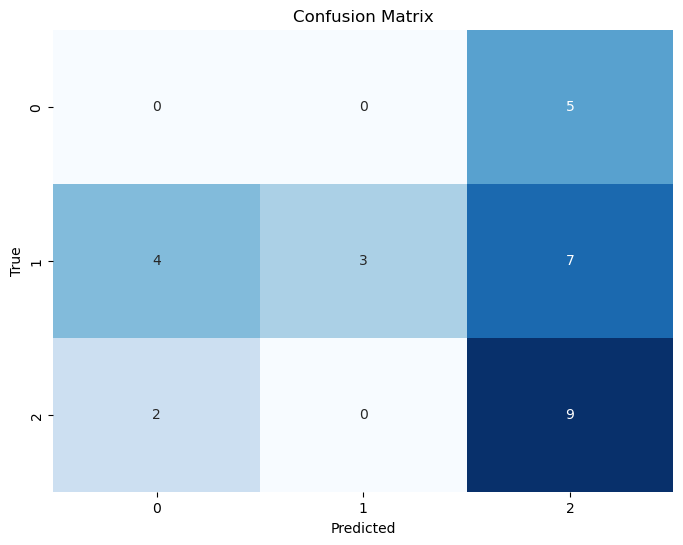

In [36]:
# Model Predictions
y_pred = model.predict(X_test)

# Evaluating model performance
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Visualizing Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Code Explanation:

#### **Step 1: Model Predictions**
- `y_pred = model.predict(X_test)`:
  - This generates predictions for the test data (`X_test`) using the trained Random Forest model.
  - The `predict()` method applies the learned model to the test features to predict the target variable (`y_pred`).

#### **Step 2: Evaluating Model Performance**
- `print("Accuracy Score:", accuracy_score(y_test, y_pred))`:
  - This calculates and prints the accuracy score of the model by comparing the true labels (`y_test`) with the predicted labels (`y_pred`).
  - The accuracy score represents the proportion of correctly predicted instances out of the total instances.

- `print("Classification Report:\n", classification_report(y_test, y_pred))`:
  - This prints a classification report that provides detailed performance metrics, including precision, recall, F1-score, and support for each class in the target variable.
  - It helps evaluate how well the model performs across different classes (in this case, accident severity).

- `print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))`:
  - This prints the confusion matrix, which shows the number of correct and incorrect predictions for each class (i.e., accident severity).
  - The matrix helps evaluate the model’s performance by providing a breakdown of true positives, false positives, true negatives, and false negatives.

#### **Step 3: Visualizing Confusion Matrix**
- `plt.figure(figsize=(8, 6))`:
  - This sets the figure size of the plot to 8 inches wide by 6 inches tall for clarity.

- `sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)`:
  - This creates a heatmap of the confusion matrix using Seaborn’s `heatmap()` function.
  - `annot=True` annotates the cells with the numeric values (counts).
  - `fmt='d'` ensures that the annotations are displayed as integers.
  - `cmap='Blues'` uses a blue color map to visualize the values.
  - `cbar=False` removes the color bar from the heatmap.

- `plt.title('Confusion Matrix')`:
  - This sets the title of the plot to "Confusion Matrix".

- `plt.xlabel('Predicted')`:
  - This labels the x-axis as 'Predicted', representing the predicted classes.

- `plt.ylabel('True')`:
  - This labels the y-axis as 'True', representing the actual true classes.

- `plt.show()`:
  - This displays the heatmap in the Jupyter notebook.

# Project Takeaway — Eko Hospital

The analysis provides Eko Hospital with a structured view of accident hotspots, timing, weather, vehicle type, traffic density, injuries, fatalities, and accident severity. These findings can support evidence-based emergency-response planning and resource-allocation discussions. The predictive model should be treated as an analytical project output rather than a clinical triage system, particularly because the dataset contains only the available accident-level factors.


# Project Findings & CV-Aligned Summary

## What I did
- Analyzed **100 traffic accident records**.
- Examined accident **locations/hotspots, time of day, weather conditions, vehicle types, traffic density, accident hour, and severity**.
- Built a **Random Forest classification model** using **5 predictive variables**: Time of Day, Weather Conditions, Vehicle Type, Traffic Density, and Accident Hour.
- Evaluated the model using **accuracy, classification report, and confusion matrix**.

## Quantified scope of the analysis
- **100** accident records analyzed.
- **3** accident-severity categories: Minor, Moderate, Severe.
- **5** model input variables.
- **4** time-of-day groups: Morning, Afternoon, Evening, Night.
- **3** traffic-density groups: Low, Medium, High.

## Who it was done for
The project was framed for **Eko Hospital**, with the analysis translated into operational insights relevant to emergency-response planning and resource allocation.

## Result and impact
The analysis provides a structured view of where and under what conditions accidents occur and produces a severity-classification workflow that can support Eko Hospital's planning around potential emergency demand.

**Important interpretation:** The available project files do not contain a verified numerical model-accuracy result or a measured percentage improvement in hospital response. Therefore, no unsupported accuracy or improvement percentage is claimed here.
